VIT Model trained on Brain MRI for stroke classification.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from PIL import Image
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from transformers import ViTForImageClassification, ViTConfig  # Required for ViT
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class BrainCTDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

def load_dataset(data_dir):
    """
    Load dataset from directory structure:
    data_dir/
        Stroke/
            image1.jpg
            image2.jpg
        Normal/
            image1.jpg
            image2.jpg
    """
    image_paths = []
    labels = []
    class_names = ['Haemorrhagic', 'Ischemic', 'Normal']

    for class_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        if os.path.exists(class_dir):
            for img_name in os.listdir(class_dir):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                    image_paths.append(os.path.join(class_dir, img_name))
                    labels.append(class_idx)

    return image_paths, labels, class_names

def create_data_augmentation():
    """Create comprehensive data augmentation for medical images"""

    # Training augmentation - aggressive for small datasets
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(15),  # Small rotation for medical images
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),  # Medical images can be flipped vertically
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
        transforms.RandomGrayscale(p=0.1),
        transforms.ToTensor(),  # Convert to tensor BEFORE tensor-only transforms
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),  # Move after ToTensor
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),  # Move after ToTensor
    ])

    # Validation/Test transform - no augmentation
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    return train_transform, val_transform

def split_data(image_paths, labels, test_size=0.2, val_size=0.2, random_state=42):
    """Split data into train, validation, and test sets"""

    # First split: train+val vs test
    X_temp, X_test, y_temp, y_test = train_test_split(
        image_paths, labels, test_size=test_size,
        random_state=random_state, stratify=labels
    )

    # Second split: train vs val
    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio,
        random_state=random_state, stratify=y_temp
    )

    print(f"Dataset split:")
    print(f"Train: {len(X_train)} images")
    print(f"Validation: {len(X_val)} images")
    print(f"Test: {len(X_test)} images")

    return X_train, X_val, X_test, y_train, y_val, y_test

class ViTBrainClassifier(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super(ViTBrainClassifier, self).__init__()

        if pretrained:
            # Use pre-trained ViT-Base
            self.vit = ViTForImageClassification.from_pretrained(
                'google/vit-base-patch16-224',
                num_labels=num_classes,
                ignore_mismatched_sizes=True
            )
        else:
            # Create ViT from scratch (for very small datasets)
            config = ViTConfig(
                image_size=224,
                patch_size=16,
                num_channels=3,
                num_classes=num_classes,
                hidden_size=768,
                num_hidden_layers=12,
                num_attention_heads=12,
                intermediate_size=3072
            )
            self.vit = ViTForImageClassification(config)

    def forward(self, x):
        outputs = self.vit(x)
        return outputs.logits

def train_model(model, train_loader, val_loader, num_epochs=25, learning_rate=1e-4):
    """Train the ViT model with early stopping"""

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)

    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5
    )

    # Training history
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    best_val_acc = 0.0
    patience_counter = 0
    patience = 10

    for epoch in range(num_epochs):
        print(f"Starting epoch {epoch+1}/{num_epochs}...")

        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        print(f"Starting training loop with {len(train_loader)} batches...")

        for batch_idx, (images, labels) in enumerate(train_loader):
            if batch_idx == 0:
                print(f"Successfully loaded first batch: images shape {images.shape}, labels shape {labels.shape}")

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

            if batch_idx % 10 == 0:
                print(f'Epoch {epoch+1}/{num_epochs}, Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}')

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        # Calculate metrics
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        print('-' * 60)

        # Learning rate scheduling
        scheduler.step(avg_val_loss)

        # Early stopping and model saving
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'Aug_dataset_vit_stroke_mri.pth')
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

    return train_losses, train_accuracies, val_losses, val_accuracies

def evaluate_model(model, test_loader, class_names):
    """Evaluate the model on test set"""
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    print(f"Test Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    return accuracy

def plot_training_history(train_losses, train_accuracies, val_losses, val_accuracies):
    """Plot training history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss plot
    ax1.plot(train_losses, label='Training Loss')
    ax1.plot(val_losses, label='Validation Loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Accuracy plot
    ax2.plot(train_accuracies, label='Training Accuracy')
    ax2.plot(val_accuracies, label='Validation Accuracy')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

def main():
    # Configuration
    DATA_DIR = "/content/drive/MyDrive/augmented_dataset"  # Update this path
    BATCH_SIZE = 256  # Small batch size for small datasets
    NUM_EPOCHS = 25
    LEARNING_RATE = 1e-4

    # Load dataset
    print("Loading dataset...")
    image_paths, labels, class_names = load_dataset(DATA_DIR)
    print(f"Total images: {len(image_paths)}")
    print(f"Classes: {class_names}")
    print(f"Class distribution: Haemorrhagic: {labels.count(0)}, Ischemic: {labels.count(1)}, Normal: {labels.count(2)}")

    # Split dataset
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(image_paths, labels)

    # Create data transforms
    train_transform, val_transform = create_data_augmentation()

    # Create datasets
    train_dataset = BrainCTDataset(X_train, y_train, transform=train_transform)
    val_dataset = BrainCTDataset(X_val, y_val, transform=val_transform)
    test_dataset = BrainCTDataset(X_test, y_test, transform=val_transform)

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=16, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=16, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=16, pin_memory=True)


    # Create model
    print("Creating ViT model...")
    model = ViTBrainClassifier(num_classes=len(class_names), pretrained=True)
    model = model.to(device)

    # Print model info
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # Train model
    print("Starting training...")
    train_losses, train_accs, val_losses, val_accs = train_model(
        model, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE
    )

    # Plot training history
    plot_training_history(train_losses, train_accs, val_losses, val_accs)

    # Load best model and evaluate
    print("Loading best model for evaluation...")
    model.load_state_dict(torch.load('Aug_dataset_vit_stroke_mri.pth'))
    test_accuracy = evaluate_model(model, test_loader, class_names)

    print(f"Final Test Accuracy: {test_accuracy:.4f}")
    torch.save(model.state_dict(), 'Aug_dataset_vit_stroke_mri.pth')
    torch.save(model, 'Aug_dataset_vit_stroke_mri.h5')


if __name__ == "__main__":
    main()

# Additional utility functions for small datasets

def create_weighted_sampler(labels):
    """Create weighted sampler for imbalanced datasets"""
    from torch.utils.data import WeightedRandomSampler

    class_counts = np.bincount(labels)
    class_weights = 1.0 / class_counts
    sample_weights = [class_weights[label] for label in labels]

    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

def apply_mixup(data, targets, alpha=0.2):
    """Apply MixUp augmentation for small datasets"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = data.size(0)
    index = torch.randperm(batch_size)

    mixed_data = lam * data + (1 - lam) * data[index, :]
    targets_a, targets_b = targets, targets[index]

    return mixed_data, targets_a, targets_b, lam

def focal_loss(inputs, targets, alpha=1, gamma=2):
    """Focal loss for handling class imbalance"""
    ce_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
    pt = torch.exp(-ce_loss)
    focal_loss = alpha * (1 - pt) ** gamma * ce_loss
    return focal_loss.mean()

# Example usage for very small datasets (< 100 images):
def small_dataset_modifications():
    """
    For very small datasets, consider these modifications:

    1. Use stronger data augmentation
    2. Reduce model size or use smaller ViT variants
    3. Apply transfer learning with frozen early layers
    4. Use techniques like MixUp, CutMix
    5. Apply focal loss for class imbalance
    6. Use k-fold cross-validation instead of single split
    """

    # Example: Freeze early layers for transfer learning
    def freeze_early_layers(model, num_layers_to_freeze=6):
        for i, (name, param) in enumerate(model.vit.vit.encoder.layer.named_parameters()):
            if i < num_layers_to_freeze:
                param.requires_grad = False

    # Example: Use smaller learning rate and longer training
    optimizer_config = {
        'lr': 5e-5,  # Smaller learning rate
        'weight_decay': 0.01,
        'eps': 1e-8
    }

    return optimizer_config

VGG16 Model trained on Brain MRI for stroke classification.

Total samples: 108000
Train: 64800, Val: 21600, Test: 21600
Class names: ['Haemorrhagic', 'Ischemic', 'Normal']
Using device: cuda


C:\Users\Sandy\miniconda3\envs\GradProject\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Sandy\miniconda3\envs\GradProject\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/25] Step [0/2025] Loss: 1.2652
Epoch [1/25] Step [15/2025] Loss: 0.8755
Epoch [1/25] Step [30/2025] Loss: 0.5521
Epoch [1/25] Step [45/2025] Loss: 0.8147
Epoch [1/25] Step [60/2025] Loss: 0.5747
Epoch [1/25] Step [75/2025] Loss: 0.7178
Epoch [1/25] Step [90/2025] Loss: 0.4792
Epoch [1/25] Step [105/2025] Loss: 0.6261
Epoch [1/25] Step [120/2025] Loss: 0.6855
Epoch [1/25] Step [135/2025] Loss: 0.5068
Epoch [1/25] Step [150/2025] Loss: 0.4516
Epoch [1/25] Step [165/2025] Loss: 0.3565
Epoch [1/25] Step [180/2025] Loss: 0.2977
Epoch [1/25] Step [195/2025] Loss: 0.3351
Epoch [1/25] Step [210/2025] Loss: 0.5289
Epoch [1/25] Step [225/2025] Loss: 0.3359
Epoch [1/25] Step [240/2025] Loss: 0.4937
Epoch [1/25] Step [255/2025] Loss: 0.2663
Epoch [1/25] Step [270/2025] Loss: 0.4387
Epoch [1/25] Step [285/2025] Loss: 0.4756
Epoch [1/25] Step [300/2025] Loss: 0.6225
Epoch [1/25] Step [315/2025] Loss: 0.2726
Epoch [1/25] Step [330/2025] Loss: 0.2660
Epoch [1/25] Step [345/2025] Loss: 0.4841


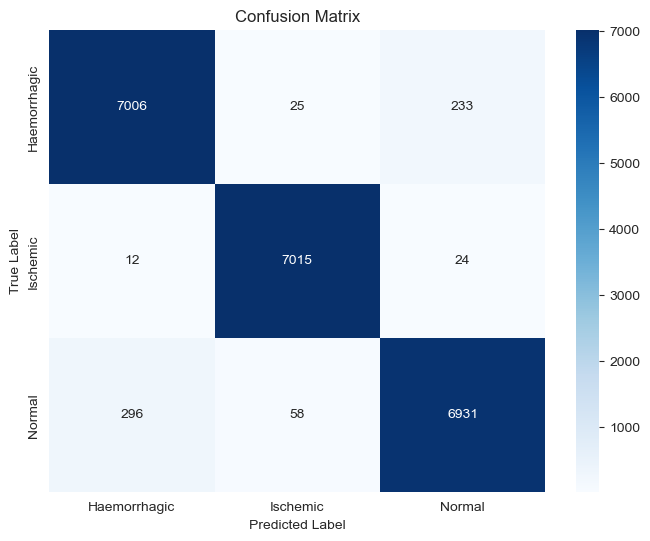

0.97

In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time

# -----------------------------
# Settings & Hyperparameters
# -----------------------------
data_dir = "Balanced_MRI_Dataset"
batch_size = 32  # reduce if using GPU with <6GB memory
img_size = 224
val_split = 0.2
test_split = 0.2
seed = 42
num_workers = 4  # increase if your CPU can handle it
epochs = 25

# -----------------------------
# Transforms
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# -----------------------------
# Dataset Loading & Splitting
# -----------------------------
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
class_names = dataset.classes

total_size = len(dataset)
val_size = int(val_split * total_size)
test_size = int(test_split * total_size)
train_size = total_size - val_size - test_size

print(f"Total samples: {total_size}")
print(f"Train: {train_size}, Val: {val_size}, Test: {test_size}")
print(f"Class names: {class_names}")

train_set, val_set, test_set = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(seed)
)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# -----------------------------
# Device Setup
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -----------------------------
# Model: VGG16 + Fine-tuned Classifier
# -----------------------------
model = models.vgg16(pretrained=True)
for param in model.features.parameters():
    param.requires_grad = False

model.classifier[6] = nn.Linear(4096, 3)  # 3 classes
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)

# -----------------------------
# Evaluation Function
# -----------------------------
def evaluate_model(model, dataloader, silent=False, confusion_matrix_plot=False):
    model.eval()
    correct, total = 0, 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = correct / total

    if not silent:
        print(classification_report(y_true, y_pred, target_names=class_names))

    if confusion_matrix_plot:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()

    return acc

# -----------------------------
# Training Function
# -----------------------------
def train_model(model, epochs=10):
    best_acc = 0
    for epoch in range(epochs):
        start = time.time()
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Batch progress logging
            if batch_idx % 15 == 0:
                print(f"Epoch [{epoch+1}/{epochs}] "
                      f"Step [{batch_idx}/{len(train_loader)}] "
                      f"Loss: {loss.item():.4f}")

        # Epoch summary
        train_acc = correct / total
        val_acc = evaluate_model(model, val_loader, silent=True)
        print(f"Epoch [{epoch+1}/{epochs}] completed in {time.time() - start:.2f}s")
        print(f"Train Accuracy: {train_acc:.4f}, Validation Accuracy: {val_acc:.4f}\n")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "Balanced_dataset_vgg16_stroke.pth")
            print(f"✅ Best model updated and saved with Val Acc: {val_acc:.4f}\n")

# -----------------------------
# Run Training
# -----------------------------
train_model(model, epochs=epochs)
# Load and Test the Best Model
# -----------------------------
model.load_state_dict(torch.load("Balanced_dataset_vgg16_stroke.pth"))
print("\n📊 Final Test Set Evaluation:")
evaluate_model(model, test_loader, confusion_matrix_plot=True)